# OFF Nutrition Data Cleaning
Applies the same cleaning pipeline used for USDA data in `eda2.ipynb` to `off_nutrition_clean.csv`.

In [1]:
import pandas as pd

df_off = pd.read_csv('off_nutrition_clean.csv', low_memory=False)
print(df_off.shape)
df_off.head()

(66341, 10)


,item_id,item_name,brand,kcal_100g,protein_100g,carbs_100g,fat_100g,serving_size,quantity,source
0,103783001,greek yogurt,Chobani,86.666667,7.333333,10.666667,1.666667,NaN,NaN,openfoodfacts
1,107972030,Fajita Chicken W/ Wholegrain Rice,Fuelhub,97.227723,10.891089,10.297030,1.049505,1 portion (505 g),NaN,openfoodfacts
2,1247,Shake Mix Vanilla Flavour,Herbalife,376.000000,36.000000,42.000000,7.200000,100.0g,NaN,openfoodfacts
3,127534563,German fine bread,NaN,263.000000,7.020000,52.630000,3.510000,2 SLICES (57 g),NaN,openfoodfacts
4,1328,Harvest whole wheat bread,"Trader Joe's, E.Leclerc",232.558140,11.627907,41.860465,4.651163,NaN,NaN,openfoodfacts


## Step 1 — Normalize `item_name`: lowercase, strip hyphens

In [2]:
df_off['item_name'] = df_off['item_name'].str.lower().str.replace('-', ' ')

## Step 2 — Cast `item_name` to string, drop float entries, filter by word count ≤ 5

In [3]:
df_off['item_name'] = df_off['item_name'].astype(str)

# Remove float-typed item names
df_off = df_off[~df_off['item_name'].apply(lambda x: isinstance(x, float))]

# Drop entries with more than 5 words in item_name
df_off['item_name_word_count'] = df_off['item_name'].str.split().apply(len)
df_off = df_off[df_off['item_name_word_count'] <= 5]

print('Rows after word-count filter:', len(df_off))

Rows after word-count filter: 56764


## Step 3 — Remove measurement/unit words and numeric entries

In [4]:
food_measurements = [
    # Weight / mass
    "mg", "milligram", "milligrams",
    "g", "gram", "grams",
    "kg", "kilogram", "kilograms",
    "oz", "ounce", "ounces",
    "lb", "lbs", "pound", "pounds",

    # Volume
    "ml", "milliliter", "milliliters", "millilitre", "millilitres",
    "cl", "centiliter", "centiliters", "centilitre", "centilitres",
    "l", "liter", "liters", "litre", "litres",
    "tsp", "teaspoon", "teaspoons",
    "tbsp", "tablespoon", "tablespoons",
    "fl oz", "fluid ounce", "fluid ounces",
    "cup", "cups",
    "pint", "pints",
    "quart", "quarts",
    "gallon", "gallons",
    "dash", "dashes",
    "pinch", "pinches",
    "splash", "splashes",
    "drop", "drops",

    # Count / piece-based
    "piece", "pieces",
    "pc", "pcs",
    "unit", "units",
    "item", "items",
    "whole", "halves", "half",
    "quarter", "quarters",
    "slice", "slices",
    "stick", "sticks",
    "cube", "cubes",
    "chunk", "chunks",
    "wedge", "wedges",
    "strip", "strips",
    "ring", "rings",
    "clove", "cloves",
    "leaf", "leaves",
    "sprig", "sprigs",
    "stalk", "stalks",
    "stem", "stems",
    "head", "heads",
    "bunch", "bunches",
    "bulb", "bulbs",
    "ear", "ears",
    "kernel", "kernels",
    "pod", "pods",
    "bean", "beans",
    "egg", "eggs",
    "fillet", "fillets",
    "breast", "breasts",
    "thigh", "thighs",
    "drumstick", "drumsticks",
    "leg", "legs",
    "wing", "wings",

    # Prepared-food / serving style
    "serving", "servings",
    "portion", "portions",
    "helping", "helpings",
    "plate", "plates",
    "bowl", "bowls",
    "dish", "dishes",
    "tray", "trays",

    # Packaging / container-based
    "pack", "packs",
    "packet", "packets",
    "package", "packages",
    "bag", "bags",
    "box", "boxes",
    "carton", "cartons",
    "can", "cans",
    "tin", "tins",
    "jar", "jars",
    "bottle", "bottles",
    "tube", "tubes",
    "sachet", "sachets",
    "wrapper", "wrappers",
    "container", "containers",
    "cupful", "cupfuls",

    # Bakery / produce / retail style
    "loaf", "loaves",
    "roll", "rolls",
    "bun", "buns",
    "patty", "patties",
    "link", "links",
    "sausage", "sausages",
    "ball", "balls",
    "bar", "bars",
    "block", "blocks",

    # Descriptive prep amounts
    "handful", "handfuls",
    "fistful", "fistfuls",
    "scoop", "scoops",
    "ladle", "ladles",
    "spoonful", "spoonfuls",
    "heaped teaspoon", "heaped teaspoons",
    "heaped tablespoon", "heaped tablespoons",
    "level teaspoon", "level teaspoons",
    "level tablespoon", "level tablespoons",
    "to taste"
]

df_off = df_off[~df_off['item_name'].str.contains('|'.join(food_measurements))]
df_off = df_off[~df_off['item_name'].str.contains(r'\d')]

print('Rows after measurement/number filter:', len(df_off))

Rows after measurement/number filter: 13164


## Step 4 — Normalize `item_name`: remove special chars, collapse spaces, strip

In [5]:
# Lowercase + hyphen→space already done; apply remaining normalizations
df_off['item_name'] = df_off['item_name'].str.replace(r'\s+', ' ', regex=True)
df_off['item_name'] = df_off['item_name'].str.replace(r'[^\w\s]', '', regex=True)
df_off['item_name'] = df_off['item_name'].str.strip()

## Step 5 — Build normalized key (`item_norm`) for deduplication

In [6]:
import re
import unicodedata

def normalize_item_name(s):
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    s = s.replace("&", " and ")
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    tokens = s.split()
    tokens = sorted(set(tokens))
    return " ".join(tokens)

df_off = df_off.copy()
df_off['item_norm'] = df_off['item_name'].apply(normalize_item_name)

print('Rows:', len(df_off))
print('Unique original:', df_off['item_name'].nunique())
print('Unique normalized:', df_off['item_norm'].nunique())
df_off[['item_name', 'item_norm']].head(20)

Rows: 13164
Unique original: 9926
Unique normalized: 8919


,item_name,item_norm
12,mk seed mix,mix mk seed
13,bakers best white bread,bakers best bread white
14,bakers best rye bread,bakers best bread rye
36,prime,prime
57,french bread,bread french
66,seasoned french croutons,croutons french seasoned
115,ciabatta bread,bread ciabatta
124,enriched white bread,bread enriched white
130,artisan ciabatta,artisan ciabatta
136,pita bread,bread pita


## Step 6 — Block-based fuzzy deduplication with rapidfuzz

In [7]:
from collections import defaultdict

df_unique = df_off.drop_duplicates(subset=['item_norm']).copy()
unique_norm_names = df_unique['item_norm'].dropna().unique()

def make_block_key(s):
    tokens = s.split()
    if not tokens:
        return ('', 0, '')
    first_token = tokens[0]
    return (first_token[:4], len(tokens), first_token[0])

blocks = defaultdict(list)
for name in unique_norm_names:
    blocks[make_block_key(name)].append(name)

block_sizes = [len(v) for v in blocks.values()]
print('Blocks:', len(blocks))
print('Largest block:', max(block_sizes))
print('Avg block size:', sum(block_sizes) / len(block_sizes))

Blocks: 3611
Largest block: 135
Avg block size: 2.469952921628358


In [8]:
from rapidfuzz import fuzz

threshold = 95
similar_pairs = []

for block_key, names in blocks.items():
    n = len(names)
    for i in range(n):
        for j in range(i + 1, n):
            score = fuzz.token_set_ratio(names[i], names[j])
            if score >= threshold:
                similar_pairs.append((names[i], names[j], score))

print('Similar pairs found:', len(similar_pairs))

Similar pairs found: 139


## Step 7 — Build clusters from pairs and choose canonical names

In [9]:
from collections import deque

graph = defaultdict(set)
for a, b, score in similar_pairs:
    graph[a].add(b)
    graph[b].add(a)

visited = set()
clusters = []

for node in graph:
    if node not in visited:
        cluster = []
        queue = deque([node])
        visited.add(node)
        while queue:
            current = queue.popleft()
            cluster.append(current)
            for neighbor in graph[current]:
                if neighbor not in visited:
                    visited.add(neighbor)
                    queue.append(neighbor)
        clusters.append(cluster)

print('Clusters found:', len(clusters))

Clusters found: 125


In [10]:
name_frequency = df_off['item_norm'].value_counts().to_dict()

canonical_map_fuzzy = {}

for cluster in clusters:
    best_name = sorted(
        cluster,
        key=lambda x: (-name_frequency.get(x, 0), len(x), x)
    )[0]
    for name in cluster:
        canonical_map_fuzzy[name] = best_name

# Identity mapping for names not in any cluster
for name in unique_norm_names:
    if name not in canonical_map_fuzzy:
        canonical_map_fuzzy[name] = name

## Step 8 — Apply canonical mapping and deduplicate

In [11]:
df_off['item_canonical'] = df_off['item_norm'].map(canonical_map_fuzzy)

df_off_dedup = df_off.drop_duplicates(subset=['item_canonical']).copy()

print('Unique normalized:', df_off['item_norm'].nunique())
print('Unique canonical:', df_off['item_canonical'].nunique())
print('Rows after dedup:', len(df_off_dedup))

Unique normalized: 8919
Unique canonical: 8782
Rows after dedup: 8782


## Step 9 — Remove duplicate words in `item_canonical` and `item_name`, then finalize

In [12]:
def remove_duplicate_words(text):
    words = str(text).split()
    seen = set()
    result = []
    for w in words:
        if w not in seen:
            seen.add(w)
            result.append(w)
    return " ".join(result)

df_off_dedup['item_canonical'] = df_off_dedup['item_canonical'].apply(remove_duplicate_words)

mask = df_off_dedup['item_name'].apply(lambda x: len(str(x).split()) != len(set(str(x).split())))
df_off_dedup.loc[mask, 'item_name'] = df_off_dedup.loc[mask, 'item_name'].apply(remove_duplicate_words)

# Replace item_name with canonical version
df_off_dedup['item_name'] = df_off_dedup['item_canonical']

# Drop helper columns
df_off_dedup = df_off_dedup.drop(columns=['item_canonical', 'item_norm'])

print('Final rows:', len(df_off_dedup))
df_off_dedup.head()

Final rows: 8782


,item_id,item_name,brand,kcal_100g,protein_100g,carbs_100g,fat_100g,serving_size,quantity,source,item_name_word_count
12,2204,mix mk seed,NaN,474.0,27.00,0.80,35.00,NaN,680 g,openfoodfacts,3
13,236555909,bakers best bread white,Wise Woodworks,235.0,8.82,50.00,1.47,1.2 ONZ (34 g),NaN,openfoodfacts,4
14,236598784,bakers best bread rye,Wise Woodworks,256.0,7.69,53.85,2.56,1 SLICE (39 g),NaN,openfoodfacts,4
36,1005798729,prime,NaN,0.0,0.02,0.00,0.00,NaN,NaN,openfoodfacts,1
57,2114016111,bread french,Winn-Dixie,228.0,8.77,45.61,1.75,2 ONZ (57 g),NaN,openfoodfacts,2


## Step 10 — Quality check & save

In [13]:
print('item_name word count distribution:')
df_off_dedup['item_name_word_count'] = df_off_dedup['item_name'].str.split().apply(len)
print(df_off_dedup['item_name_word_count'].value_counts())

single_entries = df_off_dedup['item_name'].value_counts()
print('\nNumber of unique item_name entries:', (single_entries == 1).sum())

duplicates_canonical = df_off_dedup[df_off_dedup.duplicated(subset=['item_name'], keep=False)]
print('Remaining duplicates in item_name:', len(duplicates_canonical))

item_name word count distribution:
item_name_word_count
2    3267
3    2401
1    1614
4    1138
5     361
0       1
Name: count, dtype: int64

Number of unique item_name entries: 8782
Remaining duplicates in item_name: 0


In [14]:
df_off_dedup.to_csv('off_data_dedup_final.csv', index=False)
print('Saved to off_data_dedup_final.csv')

Saved to off_data_dedup_final.csv


## Phase 2 — Apply L1/L2/L3 Ontology to OFF dataset

The OFF dataset has no `cat` column, so we classify directly from `item_name`
using the **same L1/L2/L3 taxonomy** that was applied to the USDA data.
We re-use `category_mapping2.csv` for L1/L2 lookups and call the LLM only for
item names that don't match any existing mapping key.

In [15]:
import pandas as pd
import json
import os
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()

# ── Rebuild the full taxonomy (same as building_ont_filter_new.ipynb) ─────
TAXONOMY = {
    "dairy & eggs": [
        "milk", "yogurt", "cheese", "butter & cream",
        "eggs", "ice cream & frozen yogurt", "dairy desserts"
    ],
    "meat": [
        "beef", "pork", "lamb & game", "processed meats & cold cuts",
        "sausages & hot dogs", "organ meats", "other meats"
    ],
    "poultry": [
        "chicken", "turkey", "other poultry"
    ],
    "fish & seafood": [
        "fresh fish", "shellfish", "canned & smoked fish",
        "frozen fish & seafood"
    ],
    "fruits": [
        "fresh fruits", "dried fruits", "canned & preserved fruits",
        "fruit juices"
    ],
    "vegetables": [
        "fresh vegetables", "frozen vegetables", "canned vegetables",
        "pickles, olives & peppers", "salads"
    ],
    "grains & pasta": [
        "bread", "pasta & noodles", "rice", "flour & corn meal",
        "cereal", "other grains"
    ],
    "baked goods": [
        "cookies & biscuits", "cakes & pastries", "pies & tarts",
        "crackers", "baking mixes", "crusts & dough", "baking additives & extracts"
    ],
    "snacks": [
        "chips & crisps", "popcorn & puffed snacks", "nuts & seeds",
        "snack bars", "other snacks"
    ],
    "sweets & confectionery": [
        "chocolate", "candy & gummy", "chewing gum & mints",
        "honey & syrups", "jams & spreads", "sugar"
    ],
    "beverages": [
        "water", "soda & soft drinks", "tea", "coffee",
        "energy & sport drinks", "alcoholic beverages",
        "powdered drinks", "other beverages"
    ],
    "condiments & sauces": [
        "ketchup & mustard", "salsa & dips", "salad dressing & mayonnaise",
        "cooking sauces", "seasoning & spices", "vinegar & oils"
    ],
    "fats & oils": [
        "vegetable & cooking oils", "butter & margarine", "other fats"
    ],
    "legumes & beans": [
        "canned beans", "dried legumes", "hummus & bean dips"
    ],
    "soups": [
        "canned soup", "prepared soup", "broth & stock"
    ],
    "prepared & frozen meals": [
        "frozen dinners & entrees", "pizza", "sandwiches & wraps",
        "prepared meals", "meal kits",
        "egg rolls, dumplings & sushi", "fast foods & restaurant foods"
    ],
    "supplements": [
        "dietary supplements", "protein powders", "sport nutrition"
    ],
    "plant-based alternatives": [
        "plant-based milk", "plant-based meat", "plant-based other"
    ],
    "other": [
        "other", "undefined"
    ],
}

L2_LIST = []
L1_FOR_L2 = {}
for l1, l2s in TAXONOMY.items():
    for l2 in l2s:
        L2_LIST.append(l2)
        L1_FOR_L2[l2] = l1

print(f"L1 categories : {len(TAXONOMY)}")
print(f"L2 categories : {len(L2_LIST)}")


L1 categories : 19
L2 categories : 92


In [16]:
# ── LLM classification function (identical to building_ont_filter_new.ipynb) ─
client = OpenAI()

SYSTEM_PROMPT = f"""You are a food classification expert.
Given a food item name, assign it to exactly ONE of these L2 categories:

{json.dumps(L2_LIST)}

RULES:
- Classify by the PRIMARY food type, not by secondary ingredients.
  "peach pie" → "pies & tarts", NOT "fresh fruits"
  "cheese pizza" → "pizza", NOT "cheese"
- Yogurt drinks, flavored milks → "yogurt" or "milk", NOT "other beverages"
- "Frozen X" → classify by X. "frozen fish" → "frozen fish & seafood"
- Protein powders, supplements → "protein powders" or "dietary supplements"
- Breads, buns, bagels, muffins, flatbreads → "bread"
- If ambiguous, prefer the more specific L2 over "other"
- Reply with ONLY the L2 category name, exactly as listed. Nothing else."""


def classify_item(name: str) -> str:
    resp = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": name},
        ],
        temperature=0,
        max_tokens=15,
    )
    return resp.choices[0].message.content.strip().lower()


# Quick smoke-test
for t in ["greek yogurt", "whole wheat bread", "orange juice", "potato chips"]:
    l2 = classify_item(t)
    print(f"  {t:30s} → {l2:30s} → L1: {L1_FOR_L2.get(l2, 'UNKNOWN')}")


  greek yogurt                   → yogurt                         → L1: dairy & eggs
  whole wheat bread              → bread                          → L1: grains & pasta
  whole wheat bread              → bread                          → L1: grains & pasta
  orange juice                   → fruit juices                   → L1: fruits
  orange juice                   → fruit juices                   → L1: fruits
  potato chips                   → chips & crisps                 → L1: snacks
  potato chips                   → chips & crisps                 → L1: snacks


In [17]:
# ── Classify all unique item_names in the OFF dataset ─────────────────────
# Each unique item_name gets an L2 (→ L1 derived) and L3 = item_name itself.

df_off_dedup = pd.read_csv("off_data_dedup_final.csv")

unique_items = df_off_dedup["item_name"].dropna().unique()
print(f"Unique item names to classify: {len(unique_items)}")

item_mapping = {}  # item_name → l2
errors = []

for i, item in enumerate(unique_items):
    try:
        l2 = classify_item(item)
        if l2 not in L2_LIST:
            errors.append((item, l2, "not in L2 list"))
            l2 = "other"
        item_mapping[item] = l2
    except Exception as e:
        errors.append((item, str(e), "api error"))
        item_mapping[item] = "other"

    if (i + 1) % 200 == 0:
        print(f"  {i+1}/{len(unique_items)} done...")

print(f"\nDone! Classified {len(item_mapping)} items.")
print(f"Errors/fallbacks: {len(errors)}")
if errors:
    print("Sample errors:")
    for item, resp, reason in errors[:10]:
        print(f"  {item} → {resp} ({reason})")


Unique item names to classify: 8781
  200/8781 done...
  200/8781 done...
  400/8781 done...
  400/8781 done...
  600/8781 done...
  600/8781 done...
  800/8781 done...
  800/8781 done...
  1000/8781 done...
  1000/8781 done...
  1200/8781 done...
  1200/8781 done...
  1400/8781 done...
  1400/8781 done...
  1600/8781 done...
  1600/8781 done...
  1800/8781 done...
  1800/8781 done...
  2000/8781 done...
  2000/8781 done...
  2200/8781 done...
  2200/8781 done...
  2400/8781 done...
  2400/8781 done...
  2600/8781 done...
  2600/8781 done...
  2800/8781 done...
  2800/8781 done...
  3000/8781 done...
  3000/8781 done...
  3200/8781 done...
  3200/8781 done...
  3400/8781 done...
  3400/8781 done...
  3600/8781 done...
  3600/8781 done...
  3800/8781 done...
  3800/8781 done...
  4000/8781 done...
  4000/8781 done...
  4200/8781 done...
  4200/8781 done...
  4400/8781 done...
  4400/8781 done...
  4600/8781 done...
  4600/8781 done...
  4800/8781 done...
  4800/8781 done...
  5000/8781 

In [18]:
# ── Apply L1/L2/L3 to the OFF dataframe ──────────────────────────────────
df_off_dedup["cat_l2"] = df_off_dedup["item_name"].map(item_mapping).fillna("other")
df_off_dedup["cat_l1"] = df_off_dedup["cat_l2"].map(L1_FOR_L2).fillna("other")
df_off_dedup["cat_l3"] = df_off_dedup["item_name"]   # finest grain = item_name itself

print("=== OFF coverage ===")
print(f"  L1 mapped: {(df_off_dedup['cat_l1'] != 'other').sum():,} / {len(df_off_dedup):,} ({(df_off_dedup['cat_l1'] != 'other').mean()*100:.1f}%)")
print(f"\nL1 distribution:")
print(df_off_dedup["cat_l1"].value_counts().to_string())


=== OFF coverage ===
  L1 mapped: 8,118 / 8,782 (92.4%)

L1 distribution:
cat_l1
grains & pasta              1263
dairy & eggs                1032
baked goods                  874
meat                         757
snacks                       668
other                        664
prepared & frozen meals      498
condiments & sauces          477
sweets & confectionery       465
fruits                       459
beverages                    407
vegetables                   362
supplements                  231
fish & seafood               192
poultry                      159
soups                        121
legumes & beans               70
plant-based alternatives      64
fats & oils                   19


In [19]:
# ── Drop "other" and filter to only L1s that exist in usda_final ─────────
usda_final = pd.read_csv("usda_final.csv")
valid_l1 = set(usda_final["cat_l1"].unique())
valid_l2 = set(usda_final["cat_l2"].unique())

print(f"Valid L1s from USDA: {sorted(valid_l1)}")

df_off_final = df_off_dedup[
    df_off_dedup["cat_l1"].isin(valid_l1) &
    df_off_dedup["cat_l2"].isin(valid_l2)
].copy()

print(f"\nOFF rows after ontology filter: {len(df_off_final):,}  (dropped {len(df_off_dedup) - len(df_off_final):,} 'other'/unmapped rows)")


Valid L1s from USDA: ['baked goods', 'beverages', 'condiments & sauces', 'dairy & eggs', 'fats & oils', 'fish & seafood', 'fruits', 'grains & pasta', 'legumes & beans', 'meat', 'plant-based alternatives', 'poultry', 'prepared & frozen meals', 'snacks', 'soups', 'supplements', 'sweets & confectionery', 'vegetables']

OFF rows after ontology filter: 7,692  (dropped 1,090 'other'/unmapped rows)


In [20]:
# ── Align OFF columns to match usda_final exactly ────────────────────────
# usda_final columns: ['item_name','carbs_100g','kcal_100g','fat_100g','protein_100g','source','cat_l1','cat_l2','cat_l3']

TARGET_COLS = usda_final.columns.tolist()
print("Target columns:", TARGET_COLS)

df_off_aligned = df_off_final[TARGET_COLS].copy()

print(f"\nOFF aligned shape : {df_off_aligned.shape}")
print(f"USDA final shape  : {usda_final.shape}")
df_off_aligned.head()


Target columns: ['item_name', 'carbs_100g', 'kcal_100g', 'fat_100g', 'protein_100g', 'source', 'cat_l1', 'cat_l2', 'cat_l3']

OFF aligned shape : (7692, 9)
USDA final shape  : (124125, 9)


,item_name,carbs_100g,kcal_100g,fat_100g,protein_100g,source,cat_l1,cat_l2,cat_l3
1,bakers best bread white,50.00,235.0,1.47,8.82,openfoodfacts,grains & pasta,bread,bakers best bread white
2,bakers best bread rye,53.85,256.0,2.56,7.69,openfoodfacts,grains & pasta,bread,bakers best bread rye
4,bread french,45.61,228.0,1.75,8.77,openfoodfacts,grains & pasta,bread,bread french
5,croutons french seasoned,33.33,333.0,20.00,6.67,openfoodfacts,snacks,other snacks,croutons french seasoned
6,bread ciabatta,50.88,246.0,0.00,8.77,openfoodfacts,grains & pasta,bread,bread ciabatta


## Phase 3 — Concatenate USDA + OFF → final combined dataset

In [21]:
# ── Concat USDA + OFF ──────────────────────────────────────────────────────
combined = pd.concat([usda_final, df_off_aligned], ignore_index=True)

print(f"USDA rows : {len(usda_final):,}")
print(f"OFF rows  : {len(df_off_aligned):,}")
print(f"Combined  : {len(combined):,}")
print(f"\nColumns   : {combined.columns.tolist()}")
print(f"\nSource distribution:")
print(combined["source"].value_counts().to_string())
print(f"\nL1 distribution:")
print(combined["cat_l1"].value_counts().to_string())


USDA rows : 124,125
OFF rows  : 7,692
Combined  : 131,817

Columns   : ['item_name', 'carbs_100g', 'kcal_100g', 'fat_100g', 'protein_100g', 'source', 'cat_l1', 'cat_l2', 'cat_l3']

Source distribution:
source
usda             124125
openfoodfacts      7692

L1 distribution:
cat_l1
snacks                      20725
condiments & sauces         15218
sweets & confectionery      14982
dairy & eggs                13306
baked goods                 12873
grains & pasta              12425
beverages                   10411
prepared & frozen meals      8577
vegetables                   8448
meat                         5930
fish & seafood               2628
soups                        2130
fruits                       1051
fats & oils                   978
plant-based alternatives      847
legumes & beans               623
poultry                       388
supplements                   277


In [22]:
# ── Dedup item_name across combined dataset (USDA takes priority) ─────────
before = len(combined)
combined = combined.drop_duplicates(subset=["item_name"], keep="first")
print(f"Removed {before - len(combined):,} cross-source duplicates on item_name")
print(f"Final combined rows: {len(combined):,}")
combined.head()


Removed 9,060 cross-source duplicates on item_name
Final combined rows: 122,757


,item_name,carbs_100g,kcal_100g,fat_100g,protein_100g,source,cat_l1,cat_l2,cat_l3
0,beef broth,0.42,4.0,0.00,0.83,usda,condiments & sauces,seasoning & spices,herbs/spices/extracts
1,broth chicken,0.42,4.0,0.00,0.83,usda,condiments & sauces,seasoning & spices,herbs/spices/extracts
2,and bean campbells ham soup,10.61,61.0,0.61,3.67,usda,soups,prepared soup,prepared soups
3,campbells soup tomato,15.00,75.0,1.25,1.67,usda,soups,prepared soup,prepared soups
4,bread farm pepperidge tuscan,50.88,263.0,2.63,8.77,usda,grains & pasta,bread,bread


In [23]:
# ── Save combined dataset ─────────────────────────────────────────────────
combined.to_csv("combined_final.csv", index=False)
print(f"Saved combined_final.csv  ({len(combined):,} rows × {len(combined.columns)} cols)")
print(f"Columns: {combined.columns.tolist()}")


Saved combined_final.csv  (122,757 rows × 9 cols)
Columns: ['item_name', 'carbs_100g', 'kcal_100g', 'fat_100g', 'protein_100g', 'source', 'cat_l1', 'cat_l2', 'cat_l3']


In [24]:
import zipfile, os

csv_path = "combined_final.csv"
zip_path = "combined_final.zip"

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED, compresslevel=9) as zf:
    zf.write(csv_path, arcname=csv_path)

original_mb = os.path.getsize(csv_path) / 1024 / 1024
zipped_mb   = os.path.getsize(zip_path)  / 1024 / 1024
print(f"Original : {original_mb:.2f} MB")
print(f"Zipped   : {zipped_mb:.2f} MB  ({zipped_mb/original_mb*100:.1f}% of original)")
print(f"Saved to : {zip_path}")


Original : 12.12 MB
Zipped   : 2.42 MB  (20.0% of original)
Saved to : combined_final.zip


In [25]:
#show the final combined dataset
combined.head()

,item_name,carbs_100g,kcal_100g,fat_100g,protein_100g,source,cat_l1,cat_l2,cat_l3
0,beef broth,0.42,4.0,0.00,0.83,usda,condiments & sauces,seasoning & spices,herbs/spices/extracts
1,broth chicken,0.42,4.0,0.00,0.83,usda,condiments & sauces,seasoning & spices,herbs/spices/extracts
2,and bean campbells ham soup,10.61,61.0,0.61,3.67,usda,soups,prepared soup,prepared soups
3,campbells soup tomato,15.00,75.0,1.25,1.67,usda,soups,prepared soup,prepared soups
4,bread farm pepperidge tuscan,50.88,263.0,2.63,8.77,usda,grains & pasta,bread,bread


In [5]:
combined

NameError: name 'combined' is not defined

## Phase 4 — Full cleaned dataset (all USDA + all OFF, no ontology filter)

In [6]:
import pandas as pd, zipfile, os

# ── Load both cleaned datasets ────────────────────────────────────────────
usda_clean = pd.read_csv("usda_data_dedup_final.csv")
off_clean  = pd.read_csv("off_data_dedup_final.csv")

# ── Shared nutrition columns present in both ──────────────────────────────
SHARED_COLS = ["item_name", "kcal_100g", "protein_100g", "carbs_100g", "fat_100g", "source"]

usda_slim = usda_clean[SHARED_COLS].copy()
off_slim  = off_clean[SHARED_COLS].copy()

# ── Concat ────────────────────────────────────────────────────────────────
all_clean = pd.concat([usda_slim, off_slim], ignore_index=True)

# ── Dedup on item_name (USDA takes priority) ──────────────────────────────
before = len(all_clean)
all_clean = all_clean.drop_duplicates(subset=["item_name"], keep="first")

print(f"USDA cleaned rows  : {len(usda_slim):,}")
print(f"OFF cleaned rows   : {len(off_slim):,}")
print(f"Combined total     : {before:,}")
print(f"After item_name dedup: {len(all_clean):,}  (removed {before - len(all_clean):,} cross-source dupes)")
print(f"\nSource distribution:")
print(all_clean["source"].value_counts().to_string())
print(f"\nColumns: {all_clean.columns.tolist()}")
all_clean.head()


USDA cleaned rows  : 130,054
OFF cleaned rows   : 8,782
Combined total     : 138,836
After item_name dedup: 129,243  (removed 9,593 cross-source dupes)

Source distribution:
source
usda             121784
openfoodfacts      7459

Columns: ['item_name', 'kcal_100g', 'protein_100g', 'carbs_100g', 'fat_100g', 'source']


,item_name,kcal_100g,protein_100g,carbs_100g,fat_100g,source
0,beef broth,4.0,0.83,0.42,0.00,usda
1,broth chicken,4.0,0.83,0.42,0.00,usda
2,and bean campbells ham soup,61.0,3.67,10.61,0.61,usda
3,basil prego sauces tomato,58.0,1.67,5.83,3.33,usda
4,campbells soup tomato,75.0,1.67,15.00,1.25,usda


In [7]:
# ── Save as CSV + ZIP ─────────────────────────────────────────────────────
csv_path = "all_clean_combined.csv"
zip_path = "all_clean_combined.zip"

all_clean.to_csv(csv_path, index=False)

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED, compresslevel=9) as zf:
    zf.write(csv_path, arcname=csv_path)

original_mb = os.path.getsize(csv_path) / 1024 / 1024
zipped_mb   = os.path.getsize(zip_path)  / 1024 / 1024

print(f"Saved  {csv_path}  ({len(all_clean):,} rows × {len(all_clean.columns)} cols)")
print(f"  CSV : {original_mb:.2f} MB")
print(f"  ZIP : {zipped_mb:.2f} MB  ({zipped_mb/original_mb*100:.1f}% of original)")


Saved  all_clean_combined.csv  (129,243 rows × 6 cols)
  CSV : 6.39 MB
  ZIP : 2.01 MB  (31.5% of original)


In [8]:
import pandas as pd, zipfile, os

# ── Load both ontology-filtered datasets ──────────────────────────────────
# usda_final.csv  → USDA with L1/L2/L3, "other" already filtered out
# combined_final.csv was deduped; we rebuild from the two source files instead
usda_ont = pd.read_csv("usda_final.csv")
off_ont  = pd.read_csv("combined_final.csv")
off_ont  = off_ont[off_ont["source"] == "openfoodfacts"].copy()

# ── Concat without deduplication ──────────────────────────────────────────
combined_all = pd.concat([usda_ont, off_ont], ignore_index=True)

print(f"USDA (ontology) rows : {len(usda_ont):,}")
print(f"OFF  (ontology) rows : {len(off_ont):,}")
print(f"Combined (no dedup)  : {len(combined_all):,}")
print(f"\nSource distribution:")
print(combined_all["source"].value_counts().to_string())
print(f"\nL1 distribution:")
print(combined_all["cat_l1"].value_counts().to_string())
combined_all.head()


USDA (ontology) rows : 124,125
OFF  (ontology) rows : 6,511
Combined (no dedup)  : 130,636

Source distribution:
source
usda             124125
openfoodfacts      6511

L1 distribution:
cat_l1
snacks                      20621
condiments & sauces         15117
sweets & confectionery      14939
dairy & eggs                13191
baked goods                 12752
grains & pasta              12078
beverages                   10374
prepared & frozen meals      8502
vegetables                   8400
meat                         5865
fish & seafood               2603
soups                        2112
fruits                       1002
fats & oils                   975
plant-based alternatives      844
legumes & beans               620
poultry                       366
supplements                   275


,item_name,carbs_100g,kcal_100g,fat_100g,protein_100g,source,cat_l1,cat_l2,cat_l3
0,beef broth,0.42,4.0,0.00,0.83,usda,condiments & sauces,seasoning & spices,herbs/spices/extracts
1,broth chicken,0.42,4.0,0.00,0.83,usda,condiments & sauces,seasoning & spices,herbs/spices/extracts
2,and bean campbells ham soup,10.61,61.0,0.61,3.67,usda,soups,prepared soup,prepared soups
3,campbells soup tomato,15.00,75.0,1.25,1.67,usda,soups,prepared soup,prepared soups
4,bread farm pepperidge tuscan,50.88,263.0,2.63,8.77,usda,grains & pasta,bread,bread


In [9]:
# ── Save as CSV + ZIP ─────────────────────────────────────────────────────
csv_path = "combined_ontology_all.csv"
zip_path = "combined_ontology_all.zip"

combined_all.to_csv(csv_path, index=False)

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED, compresslevel=9) as zf:
    zf.write(csv_path, arcname=csv_path)

original_mb = os.path.getsize(csv_path) / 1024 / 1024
zipped_mb   = os.path.getsize(zip_path)  / 1024 / 1024

print(f"Saved  {csv_path}  ({len(combined_all):,} rows × {len(combined_all.columns)} cols)")
print(f"Columns: {combined_all.columns.tolist()}")
print(f"  CSV : {original_mb:.2f} MB")
print(f"  ZIP : {zipped_mb:.2f} MB  ({zipped_mb/original_mb*100:.1f}% of original)")


Saved  combined_ontology_all.csv  (130,636 rows × 9 cols)
Columns: ['item_name', 'carbs_100g', 'kcal_100g', 'fat_100g', 'protein_100g', 'source', 'cat_l1', 'cat_l2', 'cat_l3']
  CSV : 12.88 MB
  ZIP : 2.57 MB  (19.9% of original)


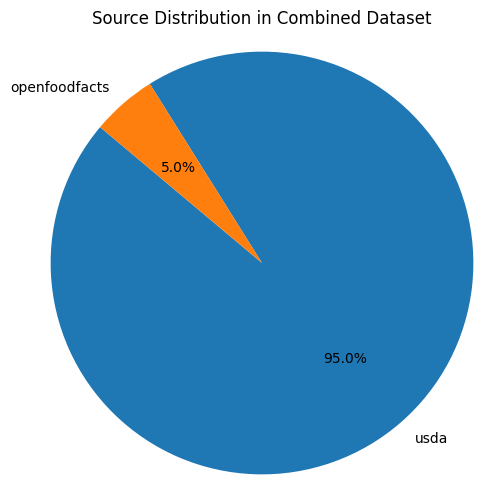

In [10]:
#get a source distribution of the combined dataset in a pie chart
import matplotlib.pyplot as plt
source_counts = combined_all["source"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(source_counts, labels=source_counts.index, autopct="%1.1f%%", startangle=140)
plt.title("Source Distribution in Combined Dataset")
plt.axis("equal")
plt.show()

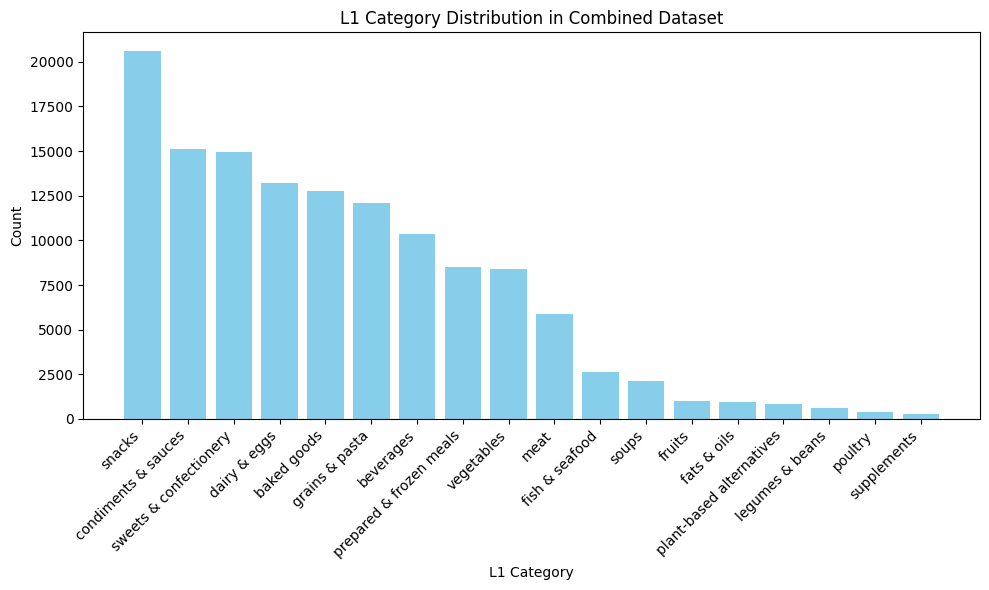

In [11]:
#show all l1 categories and their counts in a bar chart
l1_counts = combined_all["cat_l1"].value_counts()
plt.figure(figsize=(10, 6))
plt.bar(l1_counts.index, l1_counts.values, color="skyblue")
plt.xlabel("L1 Category")
plt.ylabel("Count")
plt.title("L1 Category Distribution in Combined Dataset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
#show list and number of all l_1 categories in the combined dataset
l1_categories = combined_all["cat_l1"].unique()
print(f"L1 Categories ({len(l1_categories)}):")
for cat in l1_categories:
    print(f"  - {cat}")

L1 Categories (18):
  - condiments & sauces
  - soups
  - grains & pasta
  - baked goods
  - snacks
  - sweets & confectionery
  - dairy & eggs
  - fruits
  - prepared & frozen meals
  - meat
  - vegetables
  - legumes & beans
  - fish & seafood
  - beverages
  - fats & oils
  - plant-based alternatives
  - poultry
  - supplements


In [14]:
#show list and number of all l_2 categories in the combined dataset
l2_categories = combined_all["cat_l2"].unique()
print(f"L2 Categories ({len(l2_categories)}):")
for cat in l2_categories:
    print(f"  - {cat}")

L2 Categories (75):
  - seasoning & spices
  - prepared soup
  - bread
  - cookies & biscuits
  - cakes & pastries
  - popcorn & puffed snacks
  - jams & spreads
  - chips & crisps
  - cheese
  - canned & preserved fruits
  - rice
  - crackers
  - frozen dinners & entrees
  - snack bars
  - other snacks
  - cooking sauces
  - prepared meals
  - processed meats & cold cuts
  - canned soup
  - salad dressing & mayonnaise
  - frozen vegetables
  - canned beans
  - yogurt
  - fresh vegetables
  - frozen fish & seafood
  - sugar
  - sausages & hot dogs
  - dairy desserts
  - powdered drinks
  - ketchup & mustard
  - candy & gummy
  - butter & cream
  - pasta & noodles
  - cereal
  - pickles, olives & peppers
  - baking mixes
  - canned vegetables
  - chocolate
  - vegetable & cooking oils
  - ice cream & frozen yogurt
  - salsa & dips
  - chewing gum & mints
  - canned & smoked fish
  - salads
  - other grains
  - tea
  - eggs
  - flour & corn meal
  - sandwiches & wraps
  - honey & syrups


In [16]:
#show all entries for exactly "banana" in the combined dataset
banana_entries = combined_all[combined_all["item_name"].str.lower() == "banana"]
print(f"Entries exactly matching 'banana': {len(banana_entries)}")
print(banana_entries[["item_name", "cat_l1", "cat_l2", "cat_l3", "source"]])

Entries exactly matching 'banana': 1
      item_name  cat_l1        cat_l2            cat_l3 source
10747    banana  snacks  other snacks  wholesome snacks   usda


In [17]:
#show the result for "banana" in the off_clean dataset before ontology filtering
banana_off_clean = off_clean[off_clean["item_name"].str.lower() == "banana"]
print(f"Entries for 'banana' in off_clean (pre-ontology): {len(banana_off_clean)}")
print(banana_off_clean[["item_name", "kcal_100g", "protein_100g", "carbs_100g", "fat_100g", "source"]])

Entries for 'banana' in off_clean (pre-ontology): 1
     item_name  kcal_100g  protein_100g  carbs_100g  fat_100g         source
3197    banana      547.0           1.0        70.0      28.0  openfoodfacts
